# Notebook 6 - Final Write-up and Export

This notebook turns the saved experiment outputs into a compact report surface.

Main functions:
1. inspect the saved figures,
2. assemble a report dashboard,
3. generate an interpretation note from the saved summaries,
4. keep the optional ablation separate from the main claim.



In [32]:
!pip install -q torch torchvision matplotlib numpy tqdm

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math, os, csv, json
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/diffusion_noise_project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_TYPES = ['gaussian', 'uniform', 'laplace']
COLORS = {'gaussian': '#4C72B0', 'uniform': '#DD8452', 'laplace': '#55A868'}
LABELS = {
    'gaussian': 'Gaussian (exact baseline)',
    'uniform': 'Uniform (matched-variance surrogate)',
    'laplace': 'Laplace (matched-variance surrogate)',
}
print(f'Torch version: {torch.__version__}')
print(f'Device: {DEVICE}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch version: 2.10.0+cu128
Device: cuda


## 1. Load the Saved Figures

This section is mainly for inspection before the final export.


Found 13 figure(s):
  beta_schedule.png


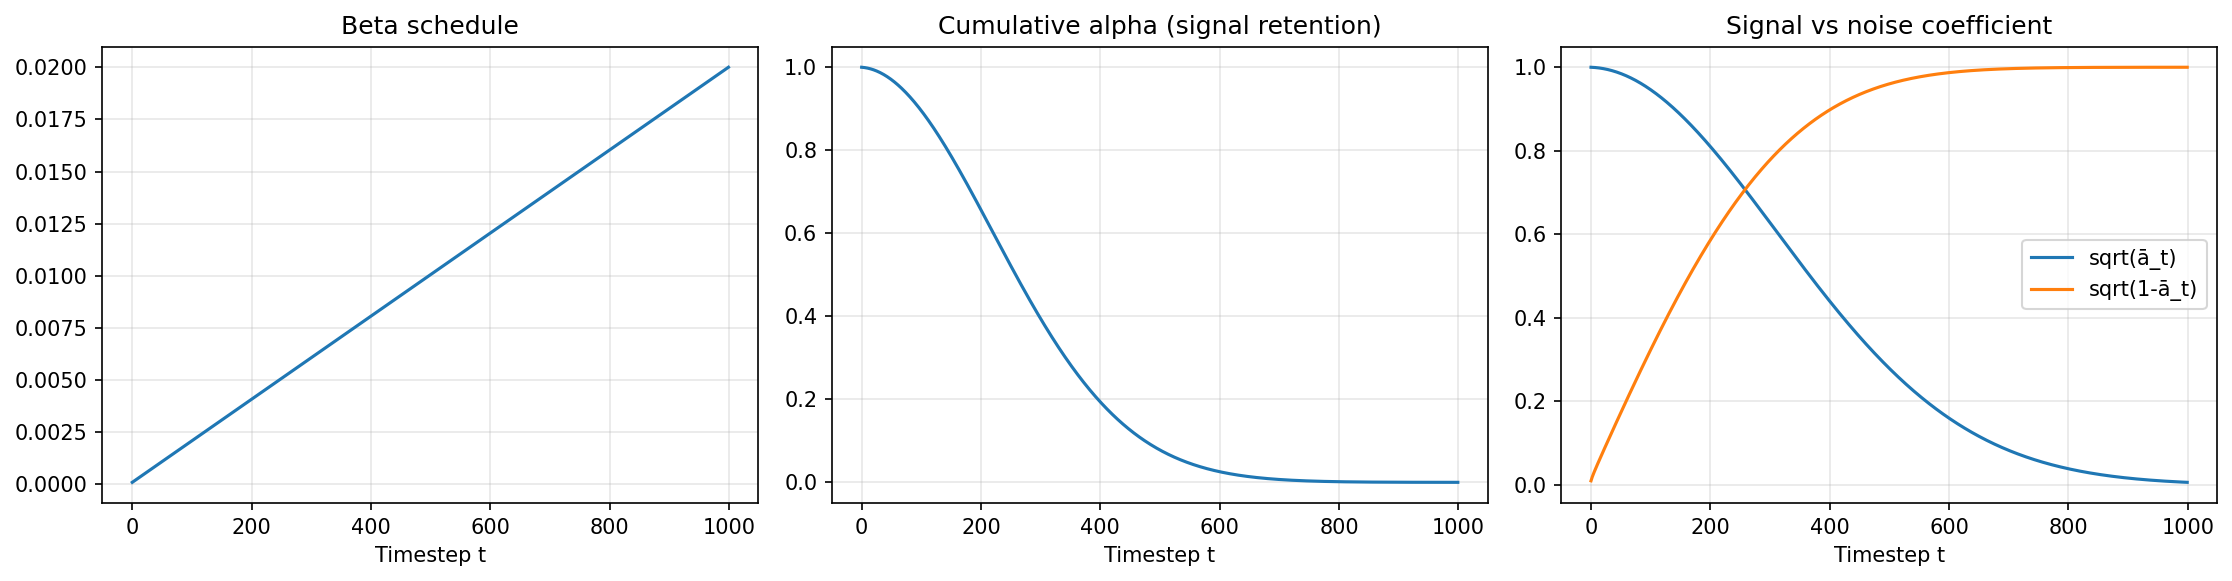

  campaign_loss_overview.png


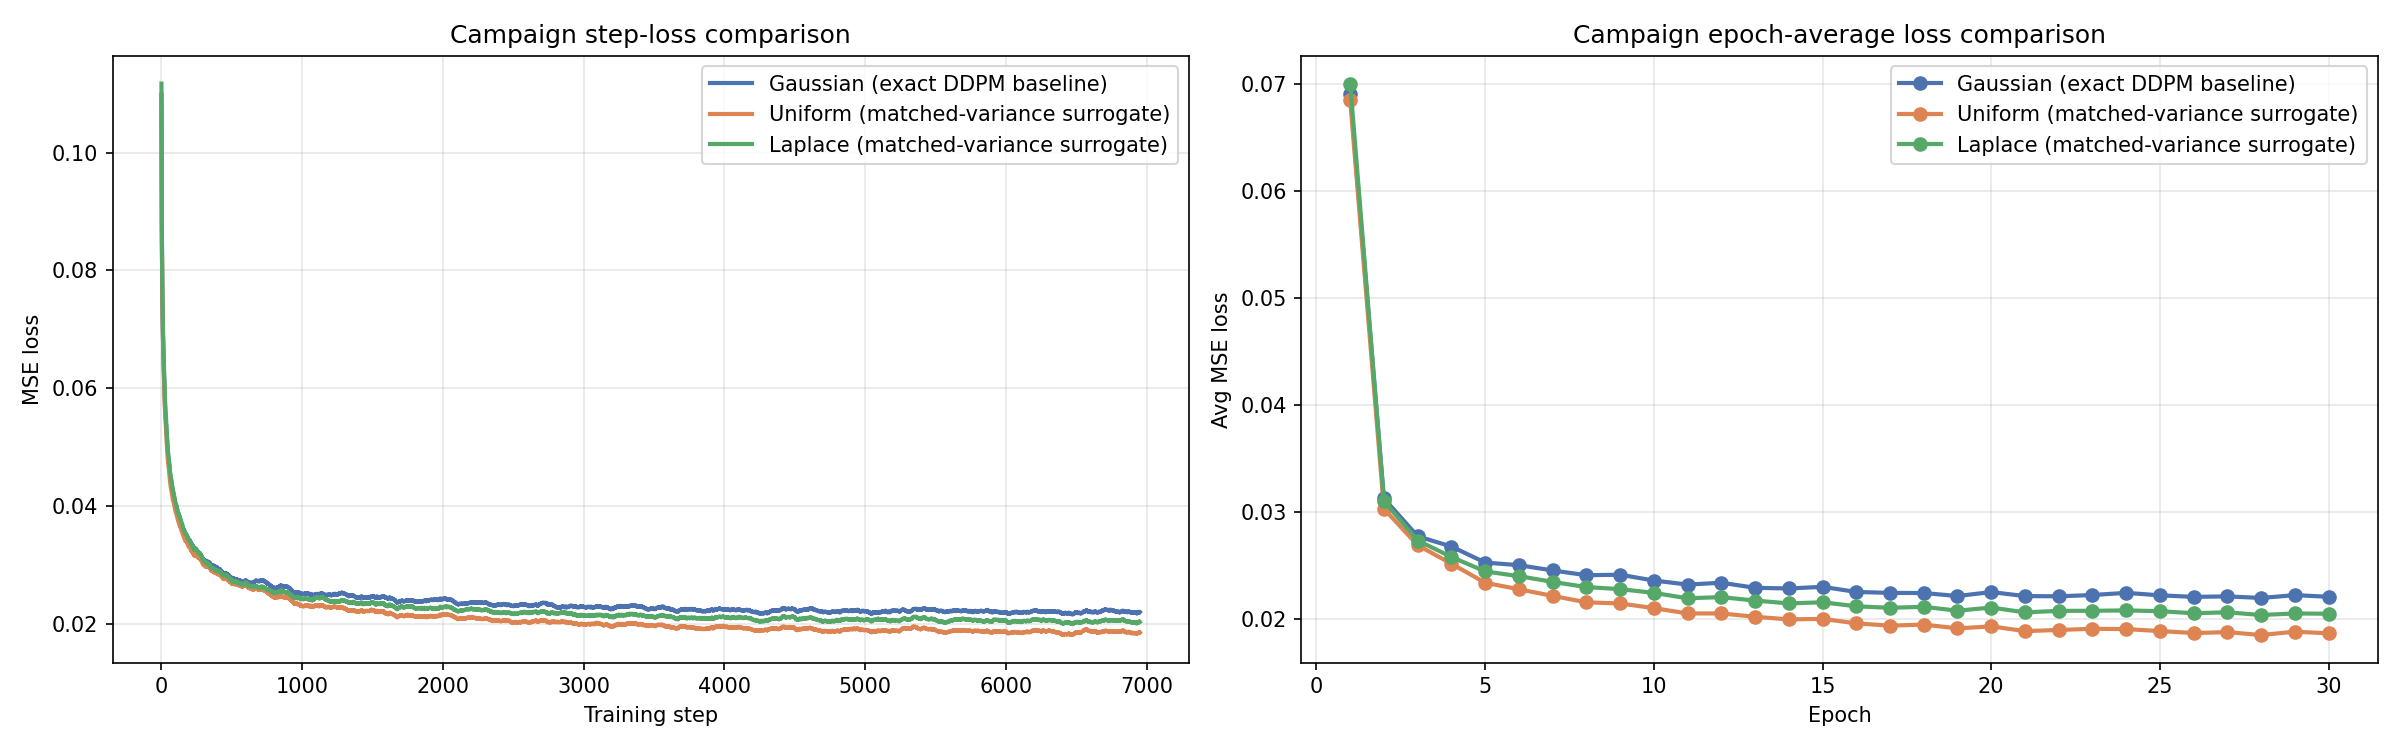

  campaign_samples.png


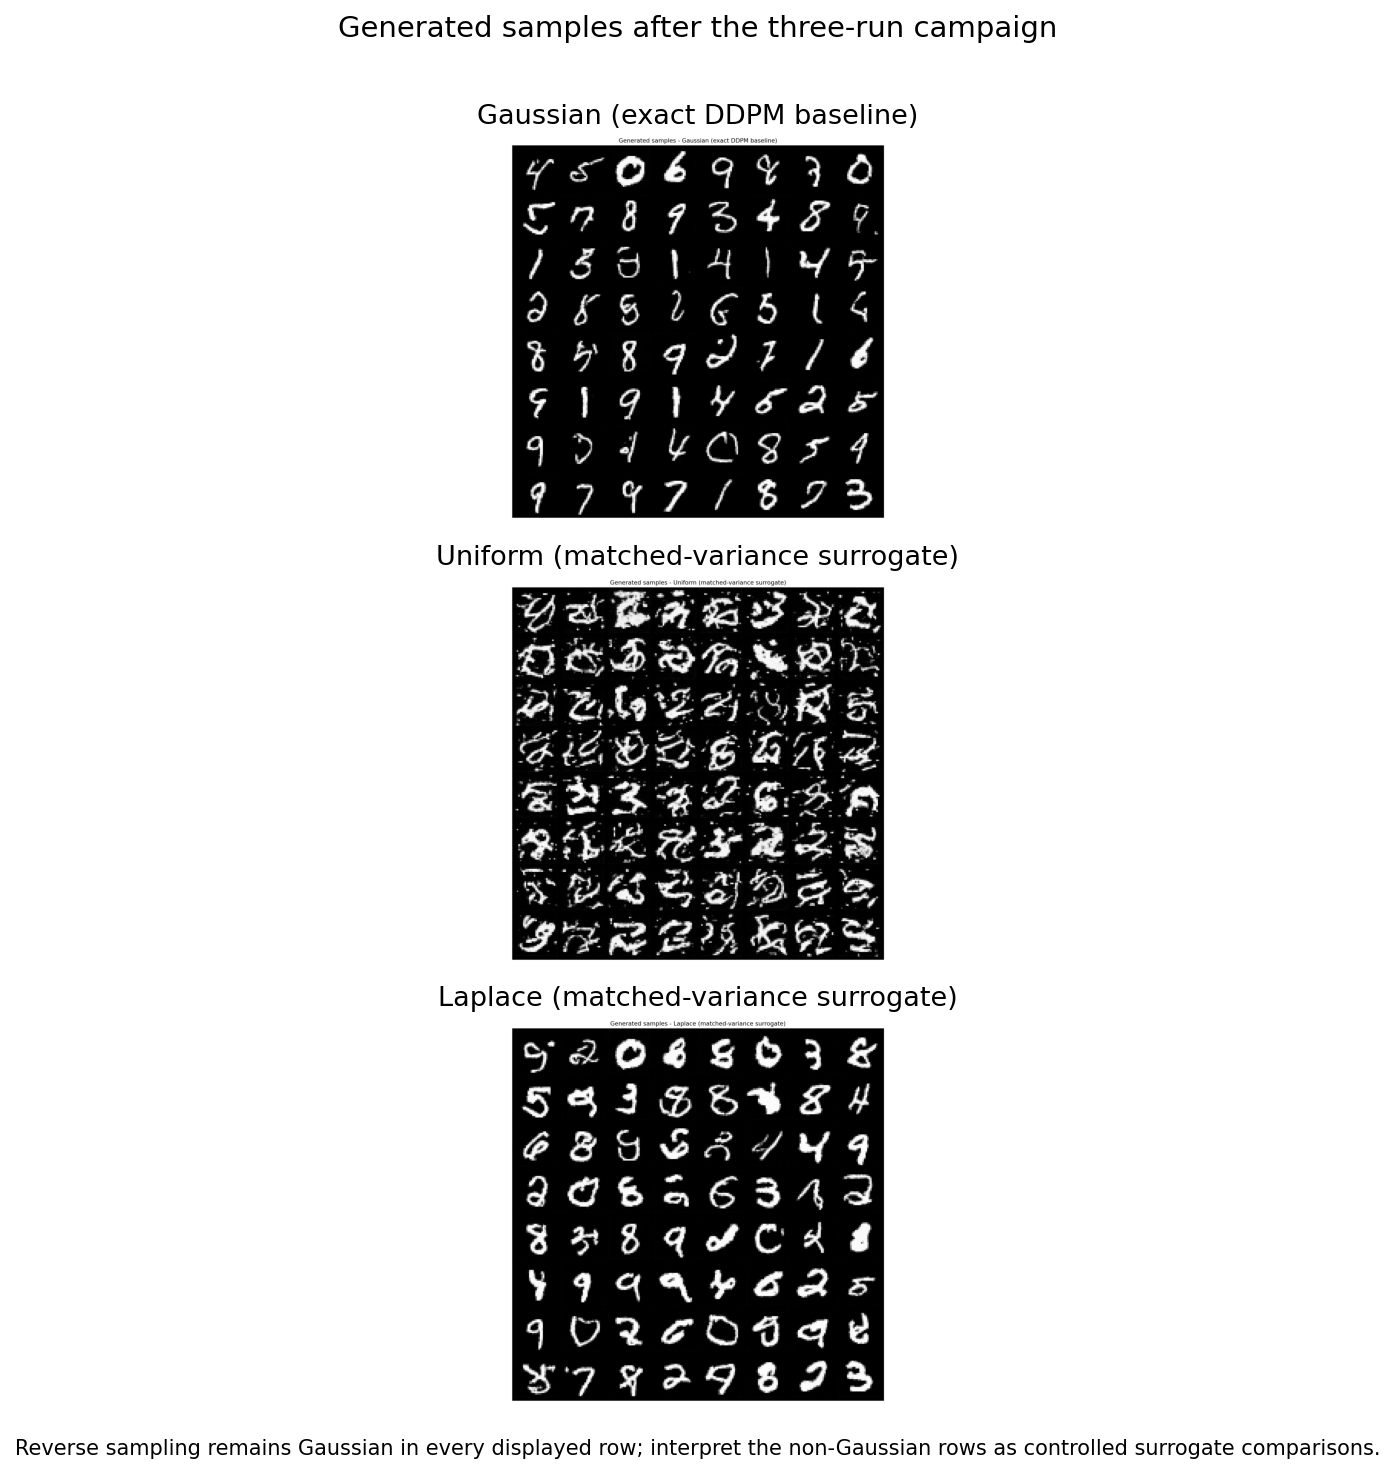

  forward_diffusion_comparison.png


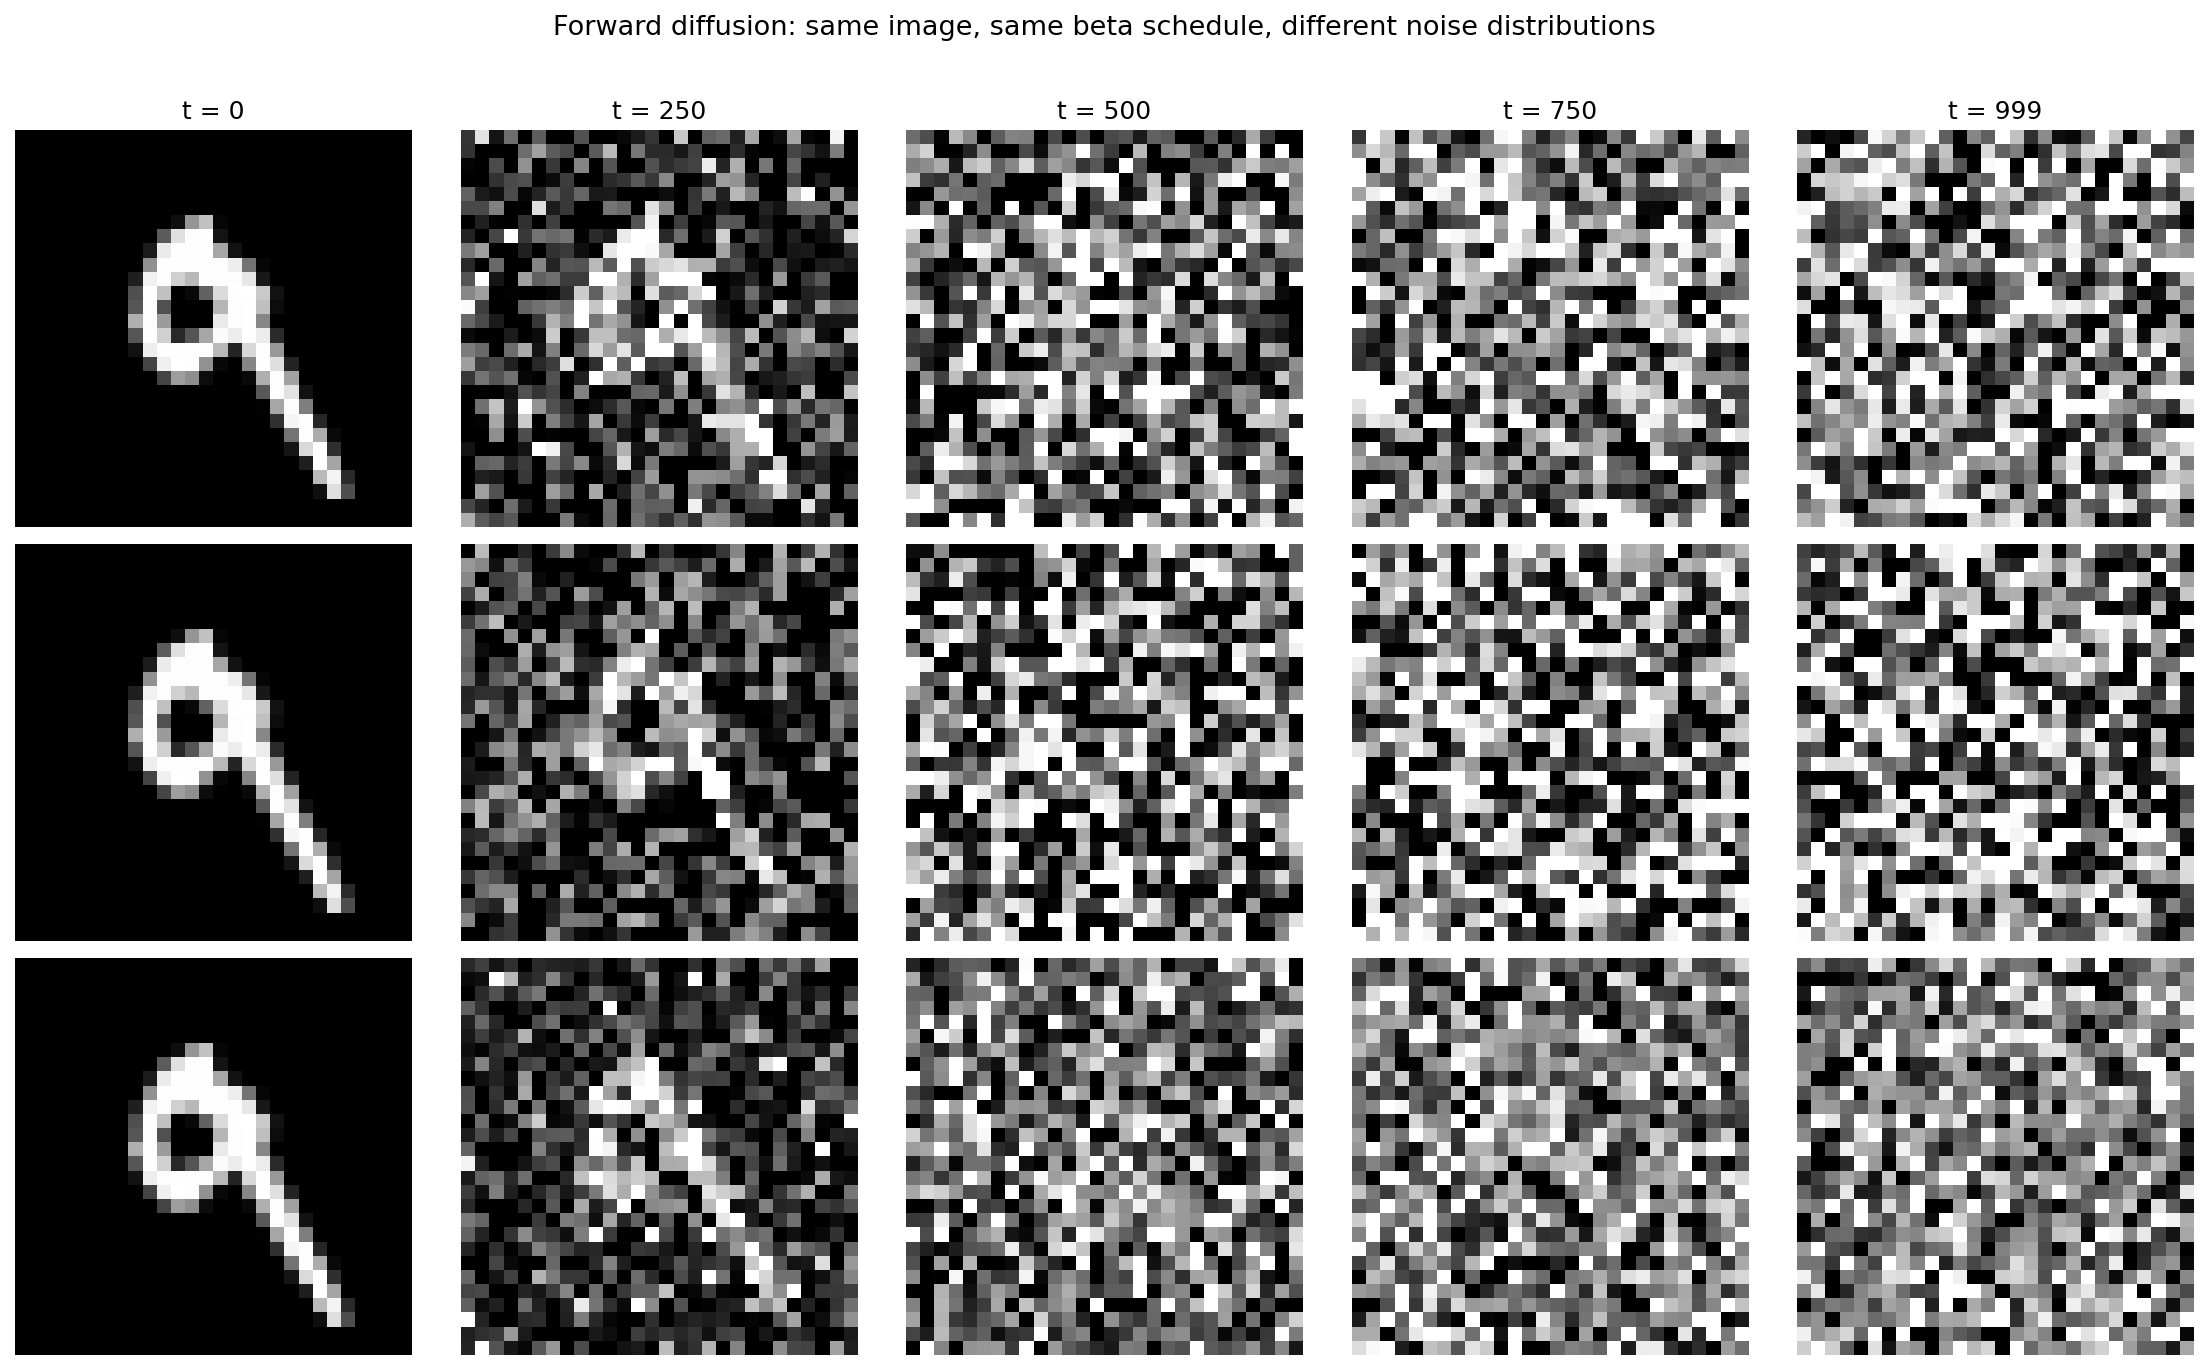

  kurtosis_diagnostic.png


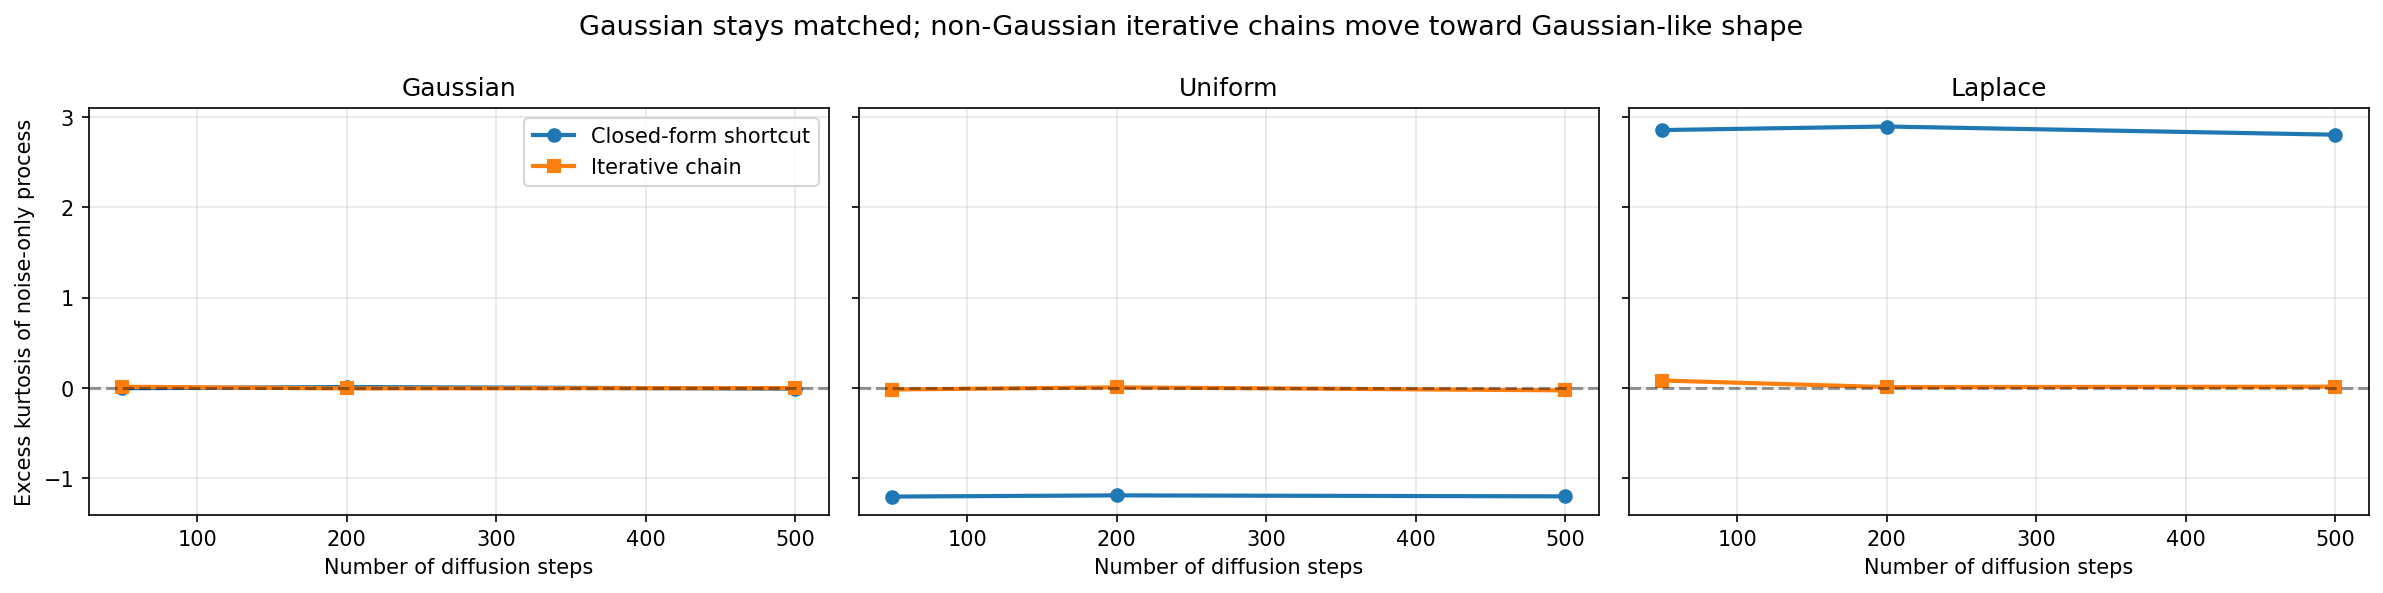

  loss_comparison.png


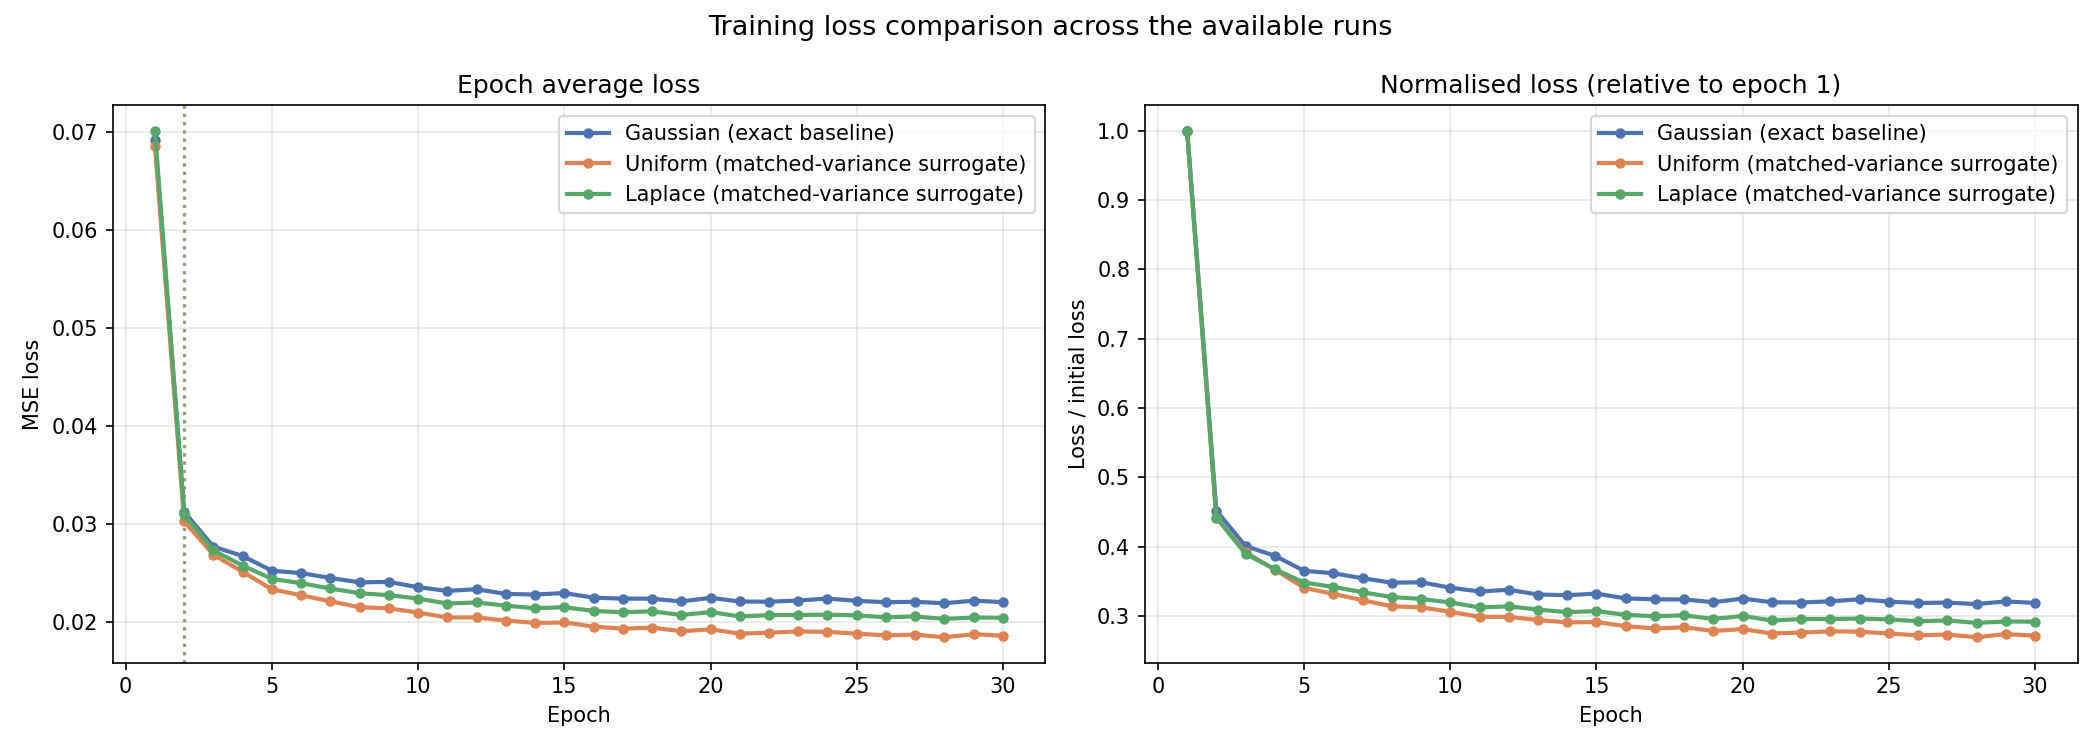

  metric_overview.png


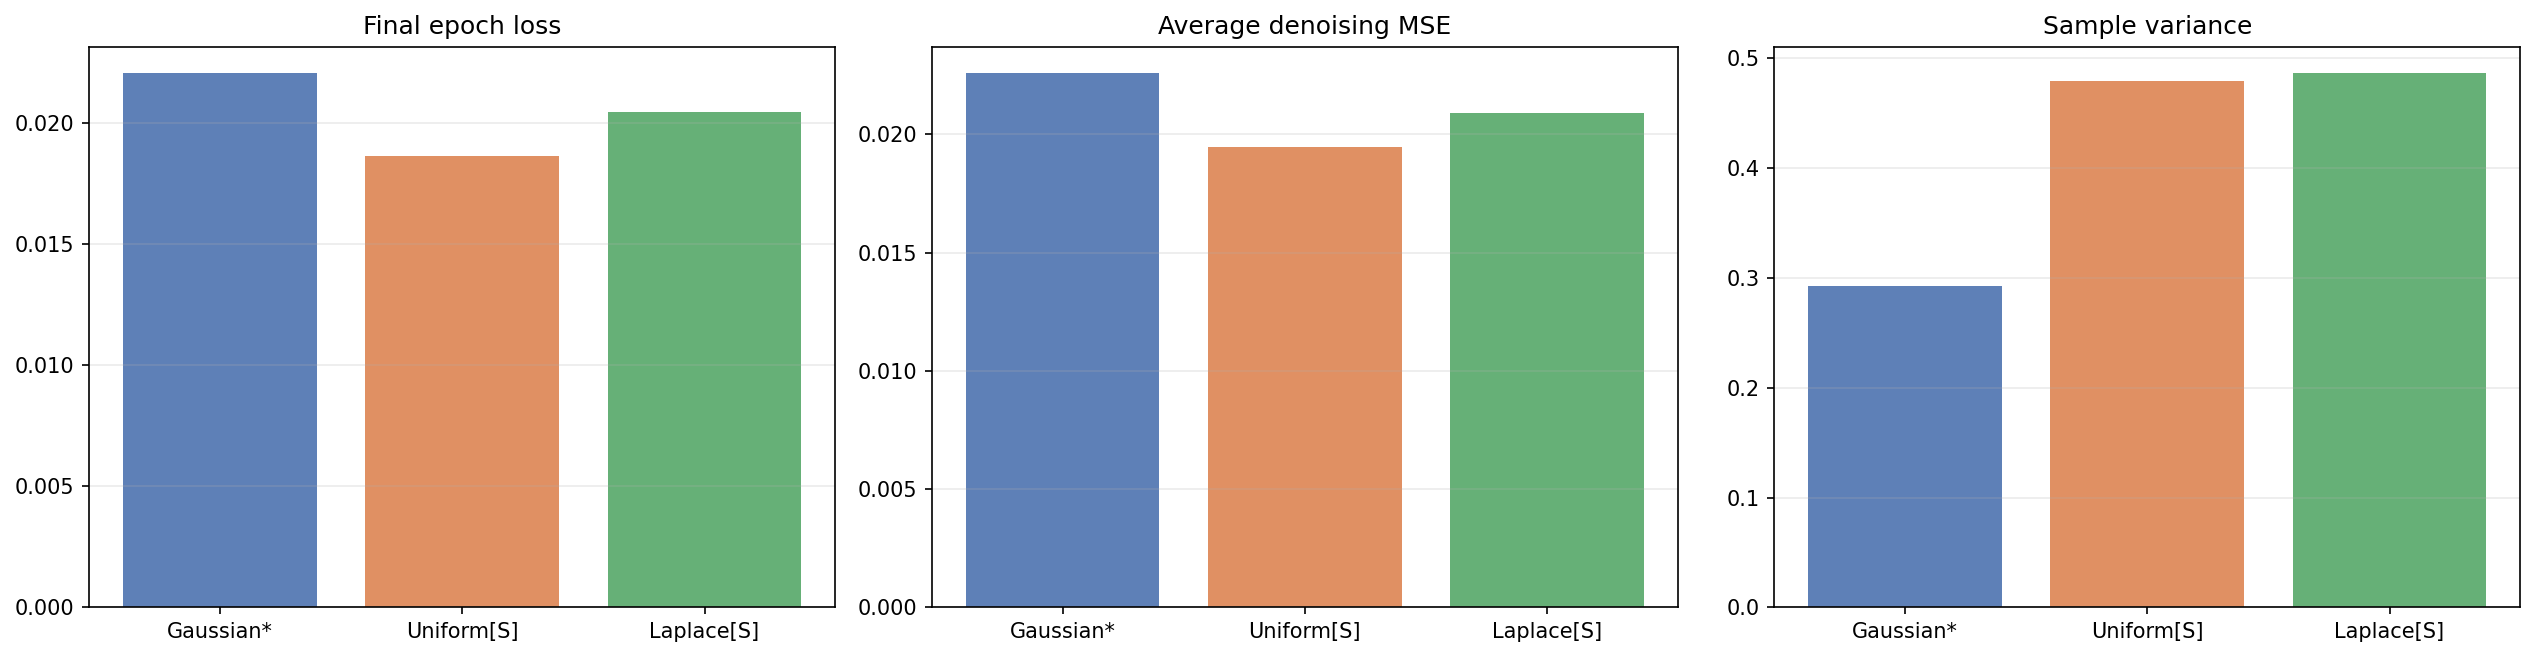

  mnist_samples.png


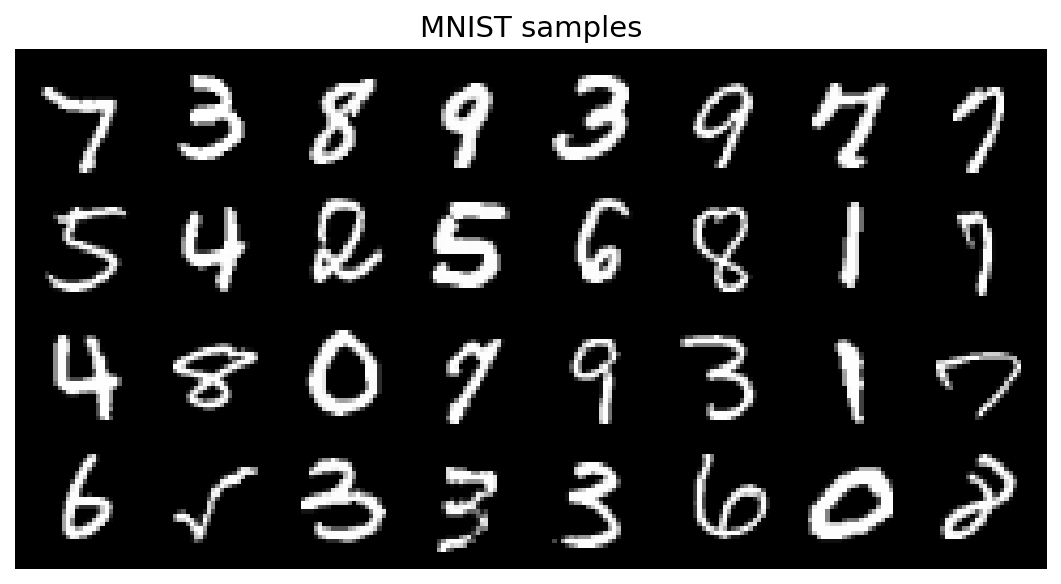

  mse_vs_timestep.png


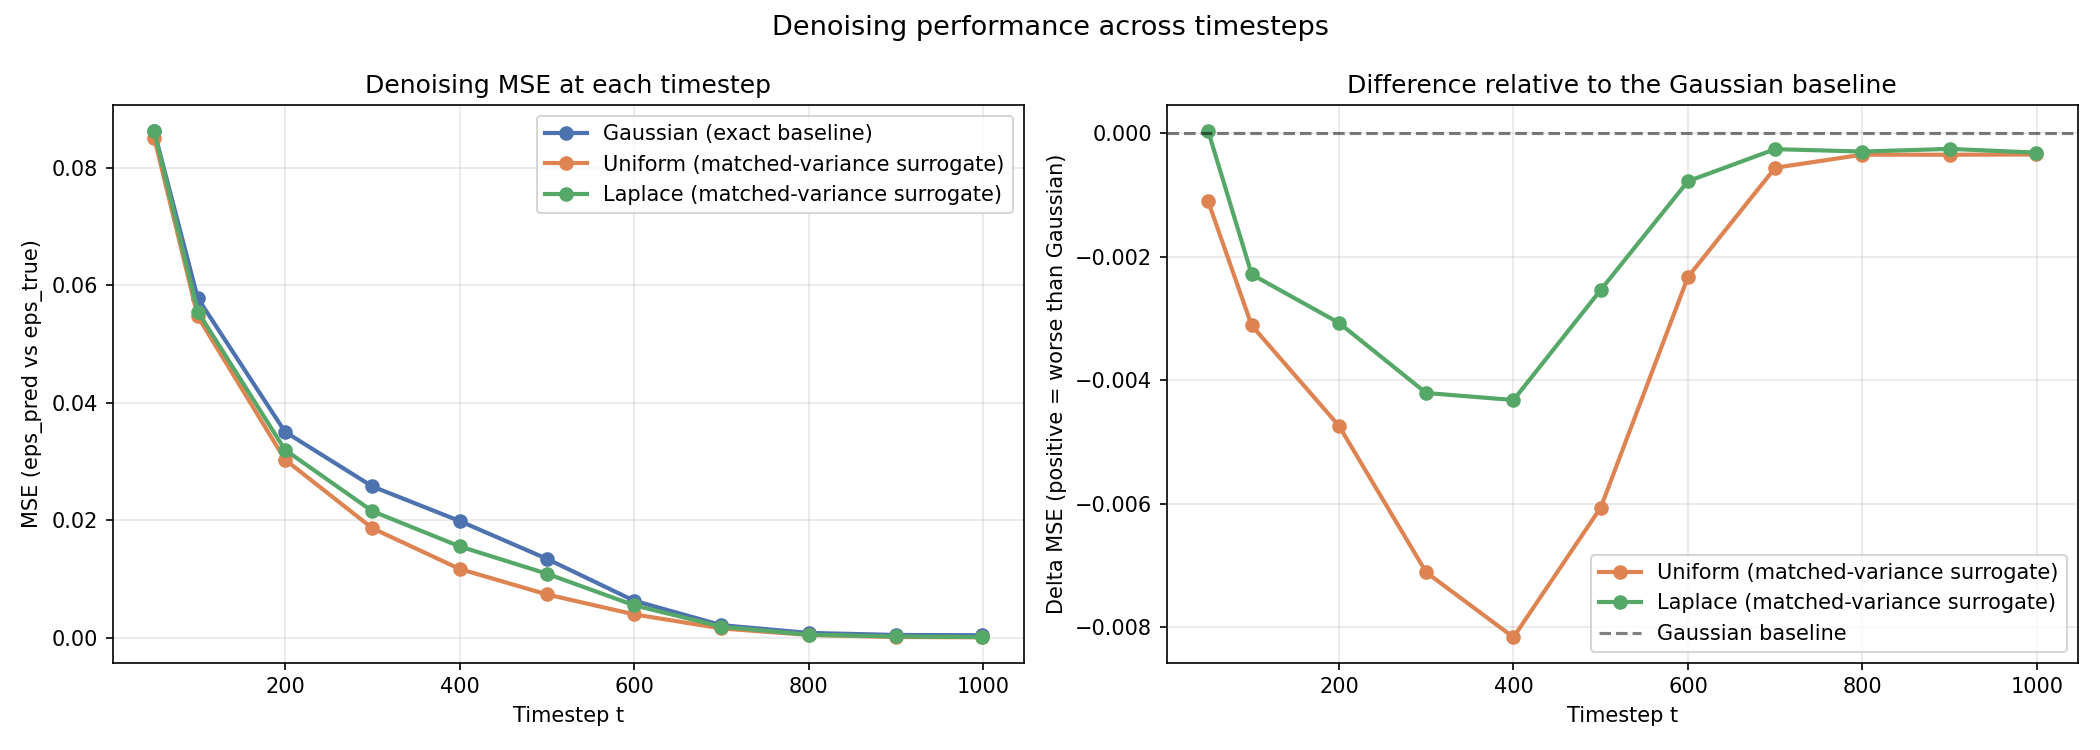

  noise_distributions.png


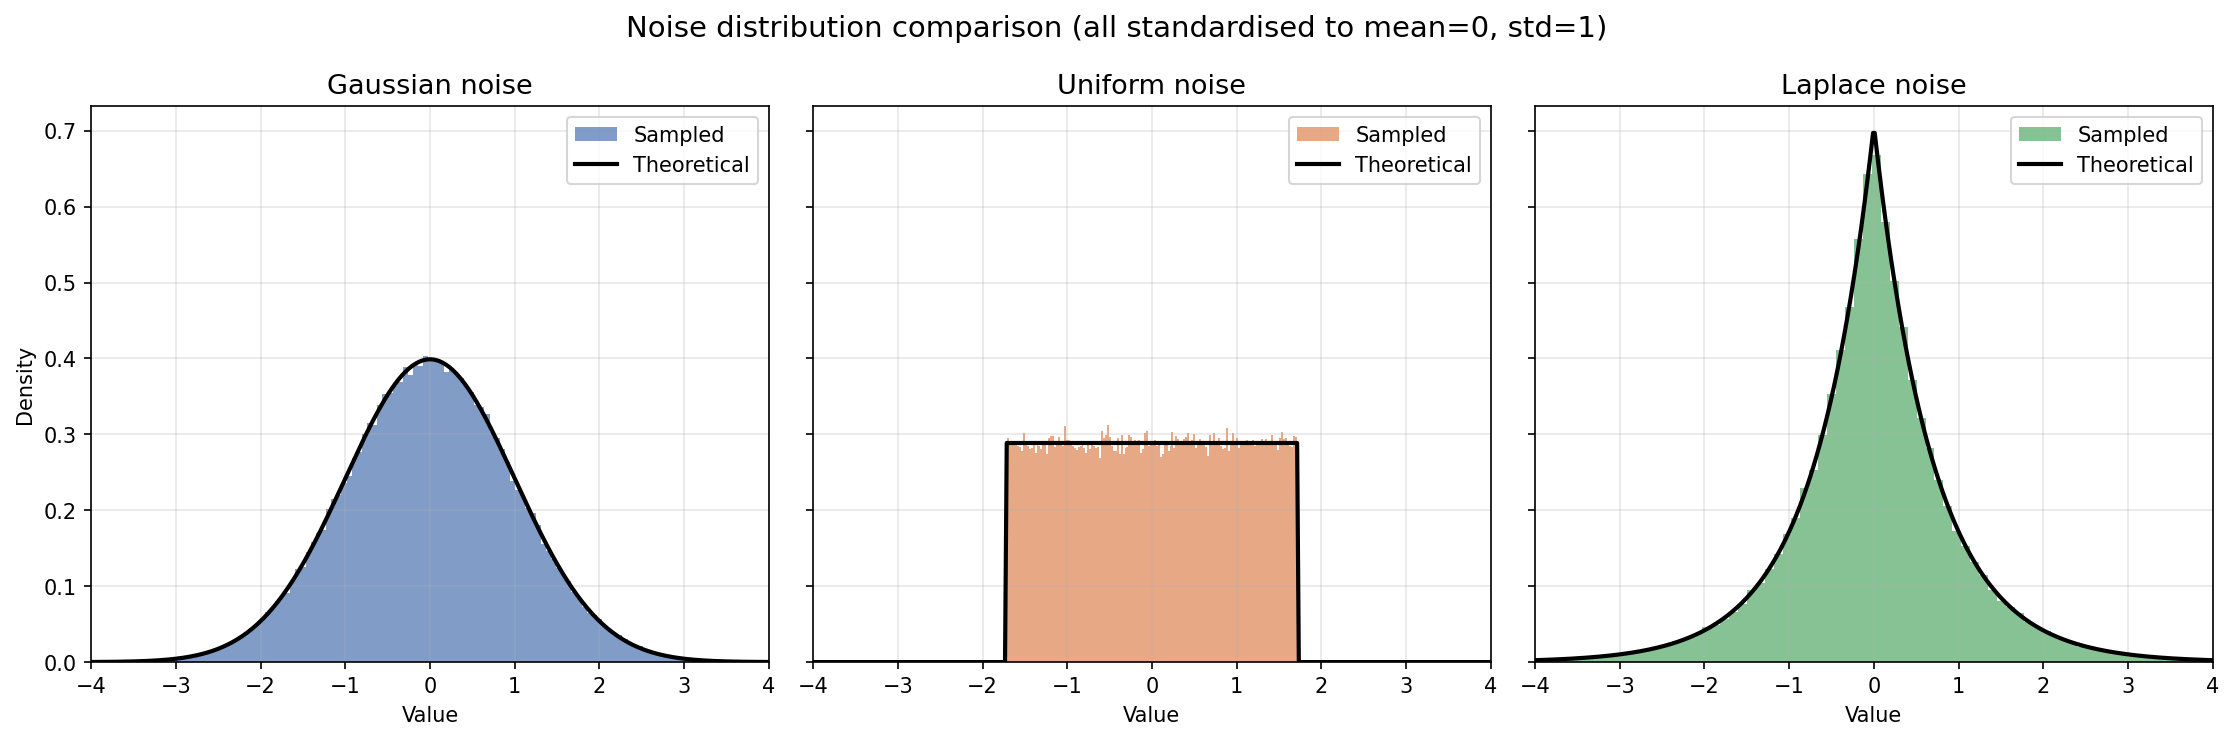

  noise_variance_vs_t.png


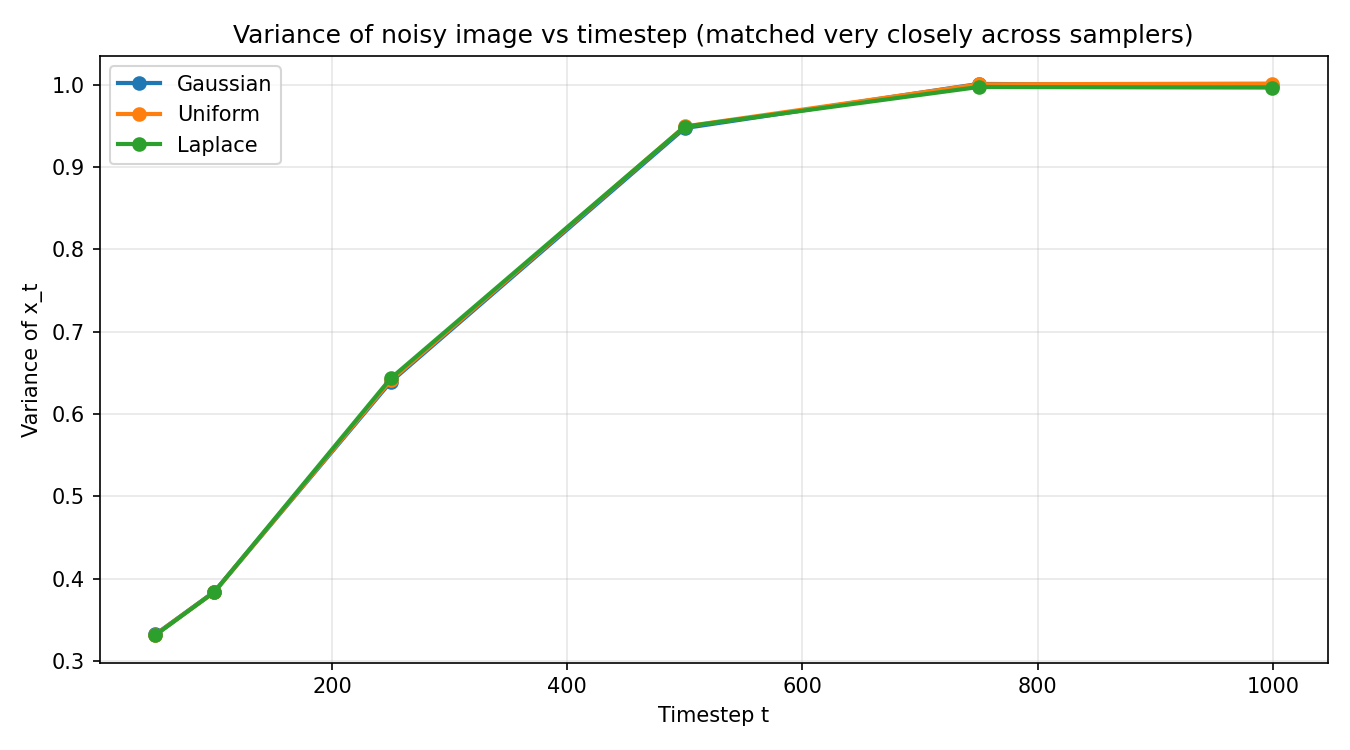

  samples_comparison.png


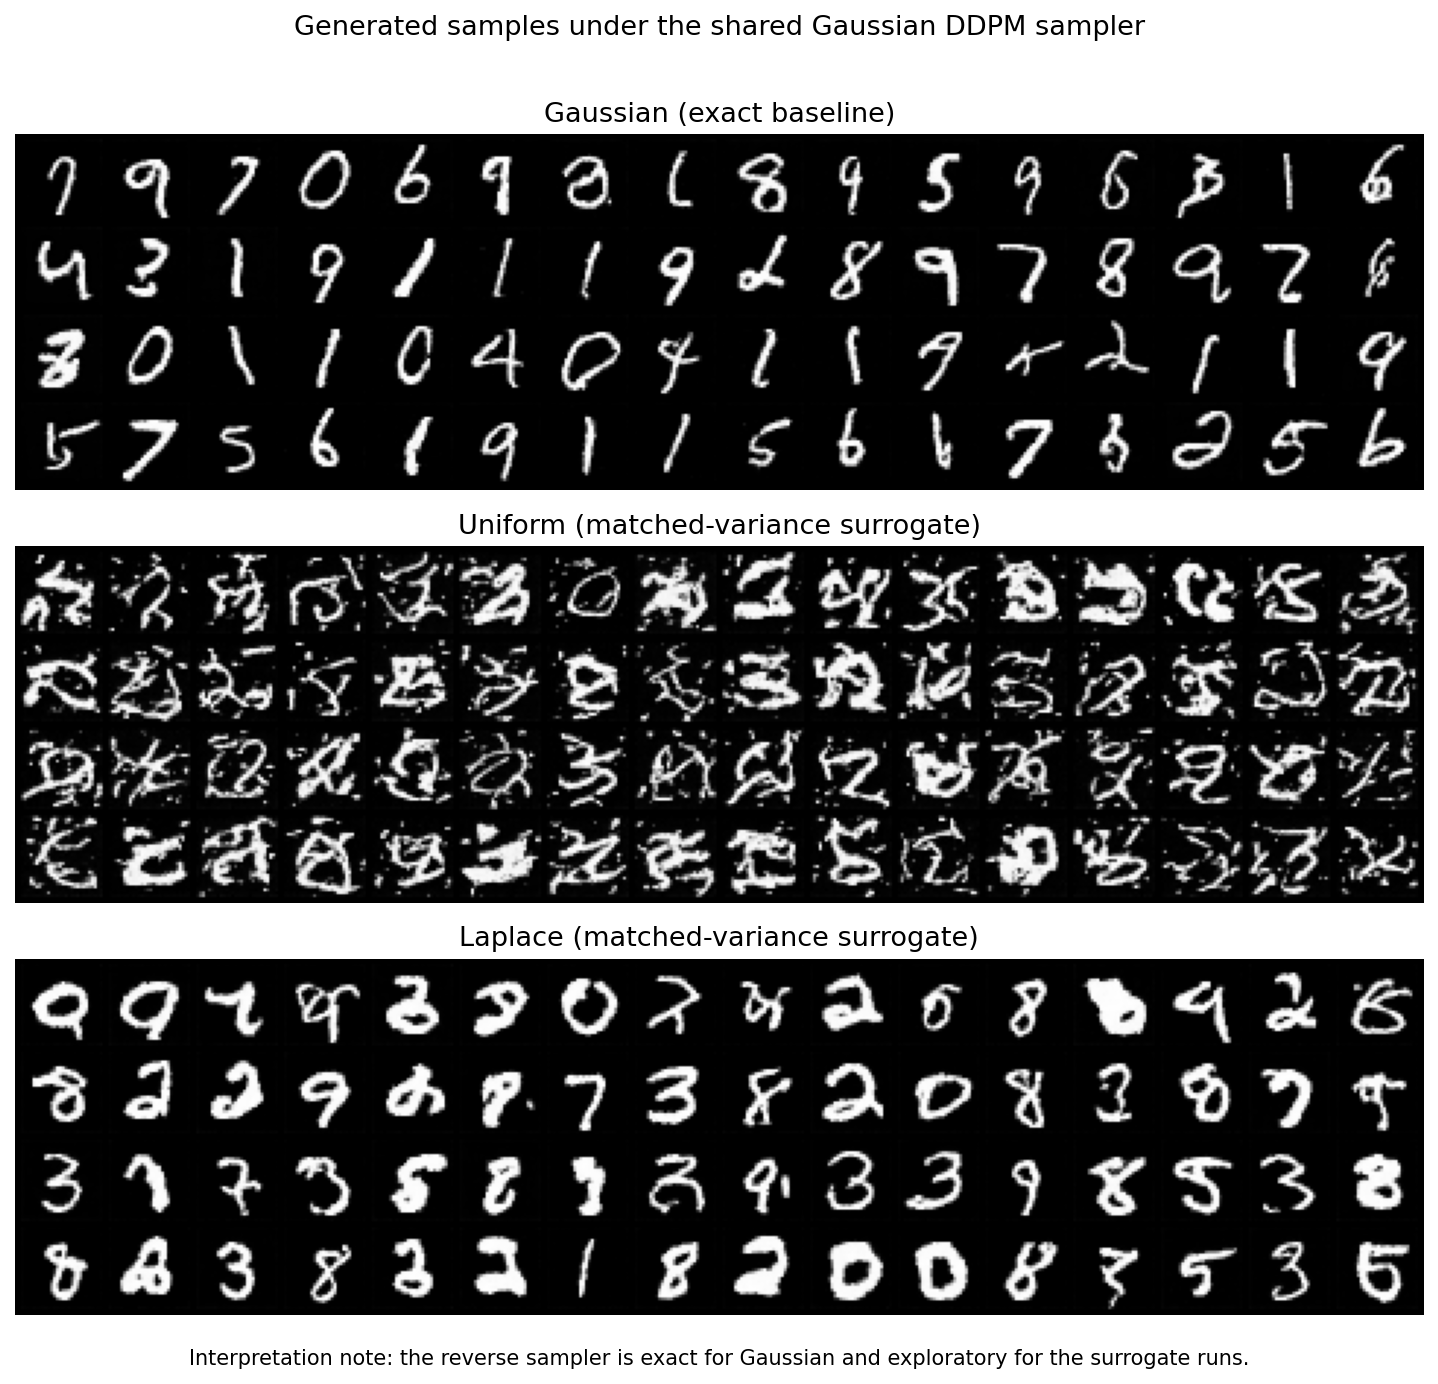

  trajectories.png


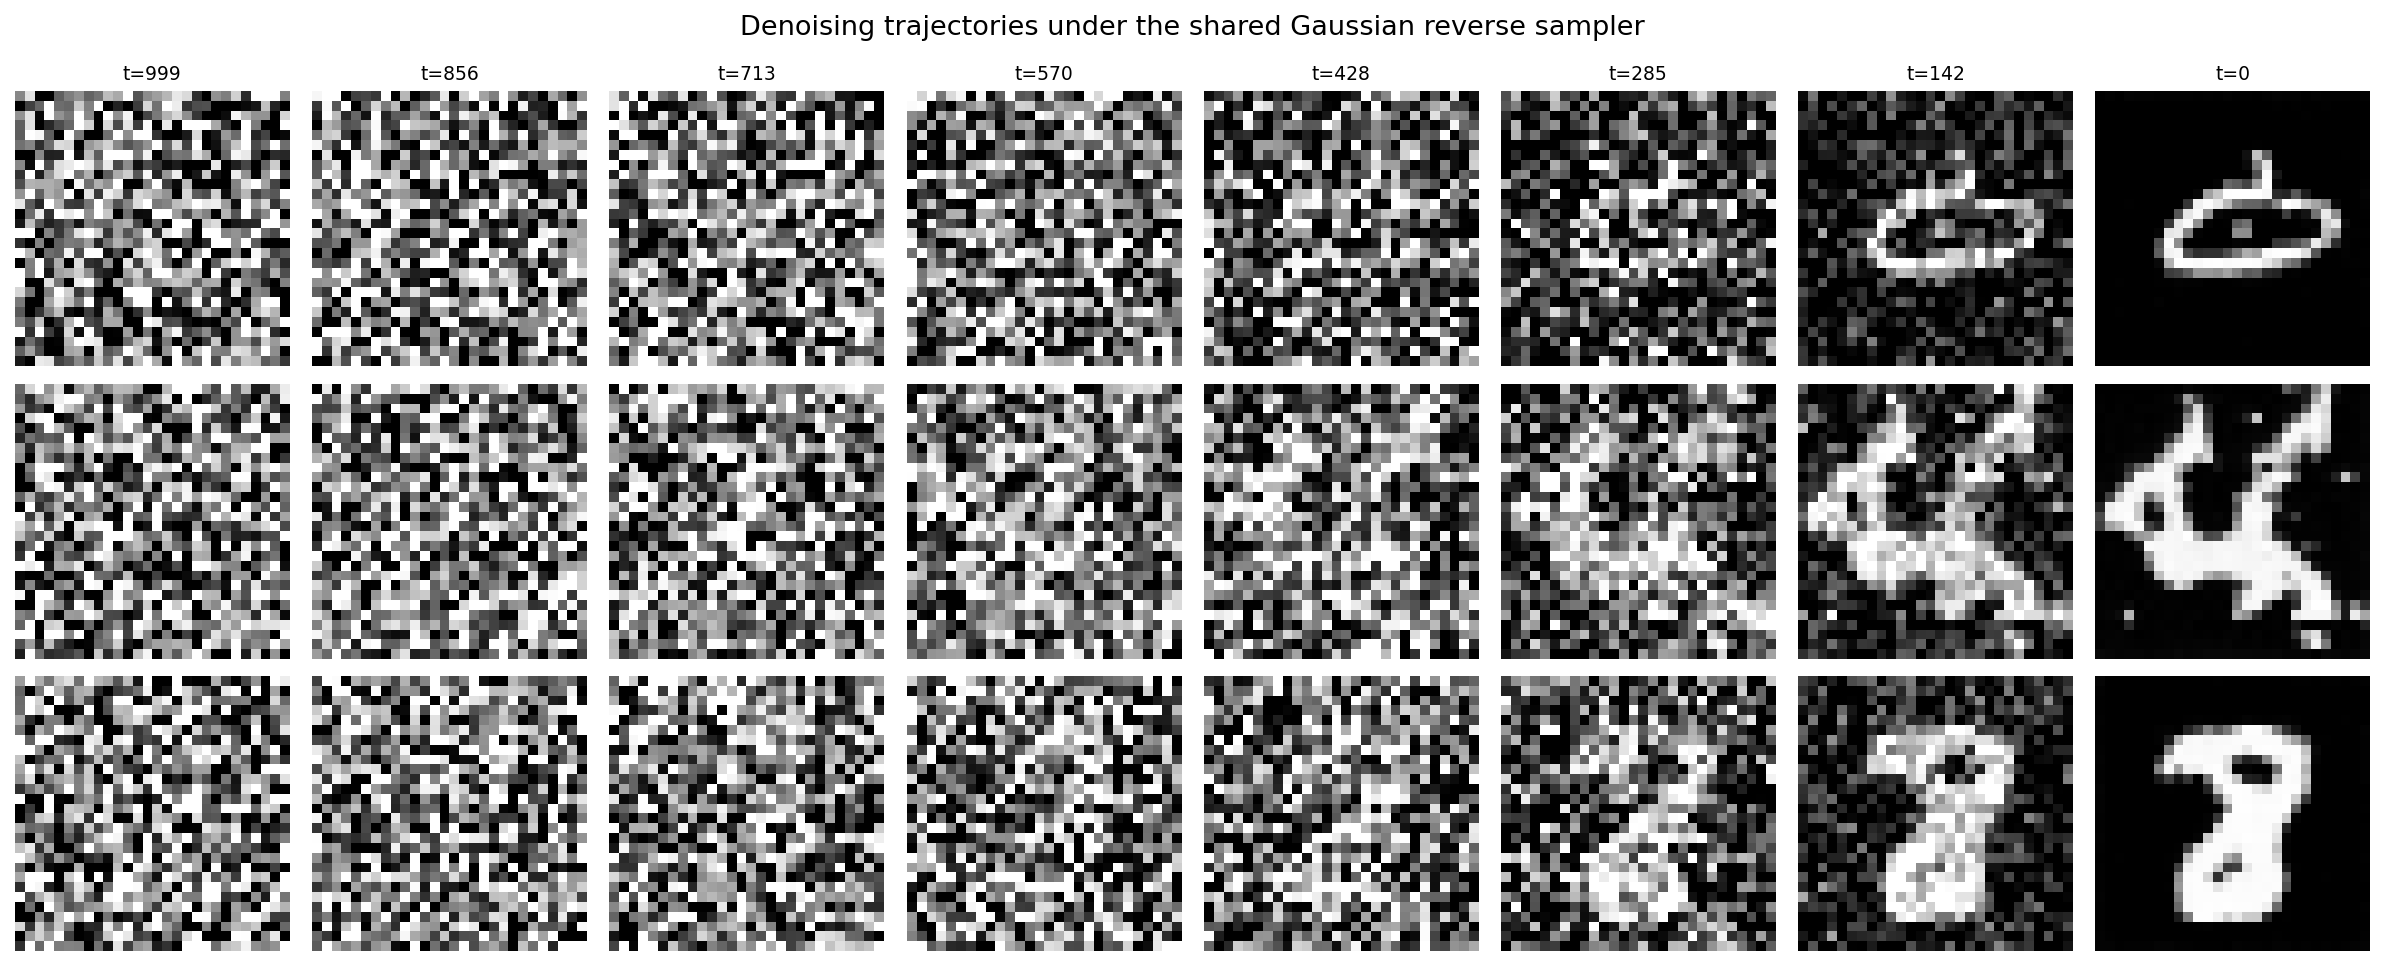

In [34]:
from IPython.display import Image, display, Markdown

fig_dir = os.path.join(PROJECT_DIR, 'figures')
fig_files = sorted(os.listdir(fig_dir)) if os.path.exists(fig_dir) else []

print(f'Found {len(fig_files)} figure(s):')
for f in fig_files:
    print(f'  {f}')
    display(Image(os.path.join(fig_dir, f), width=900))


## 2. Report Dashboard

The dashboard below prioritizes the full campaign outputs and the methodological diagnostic rather than repeating the training code.



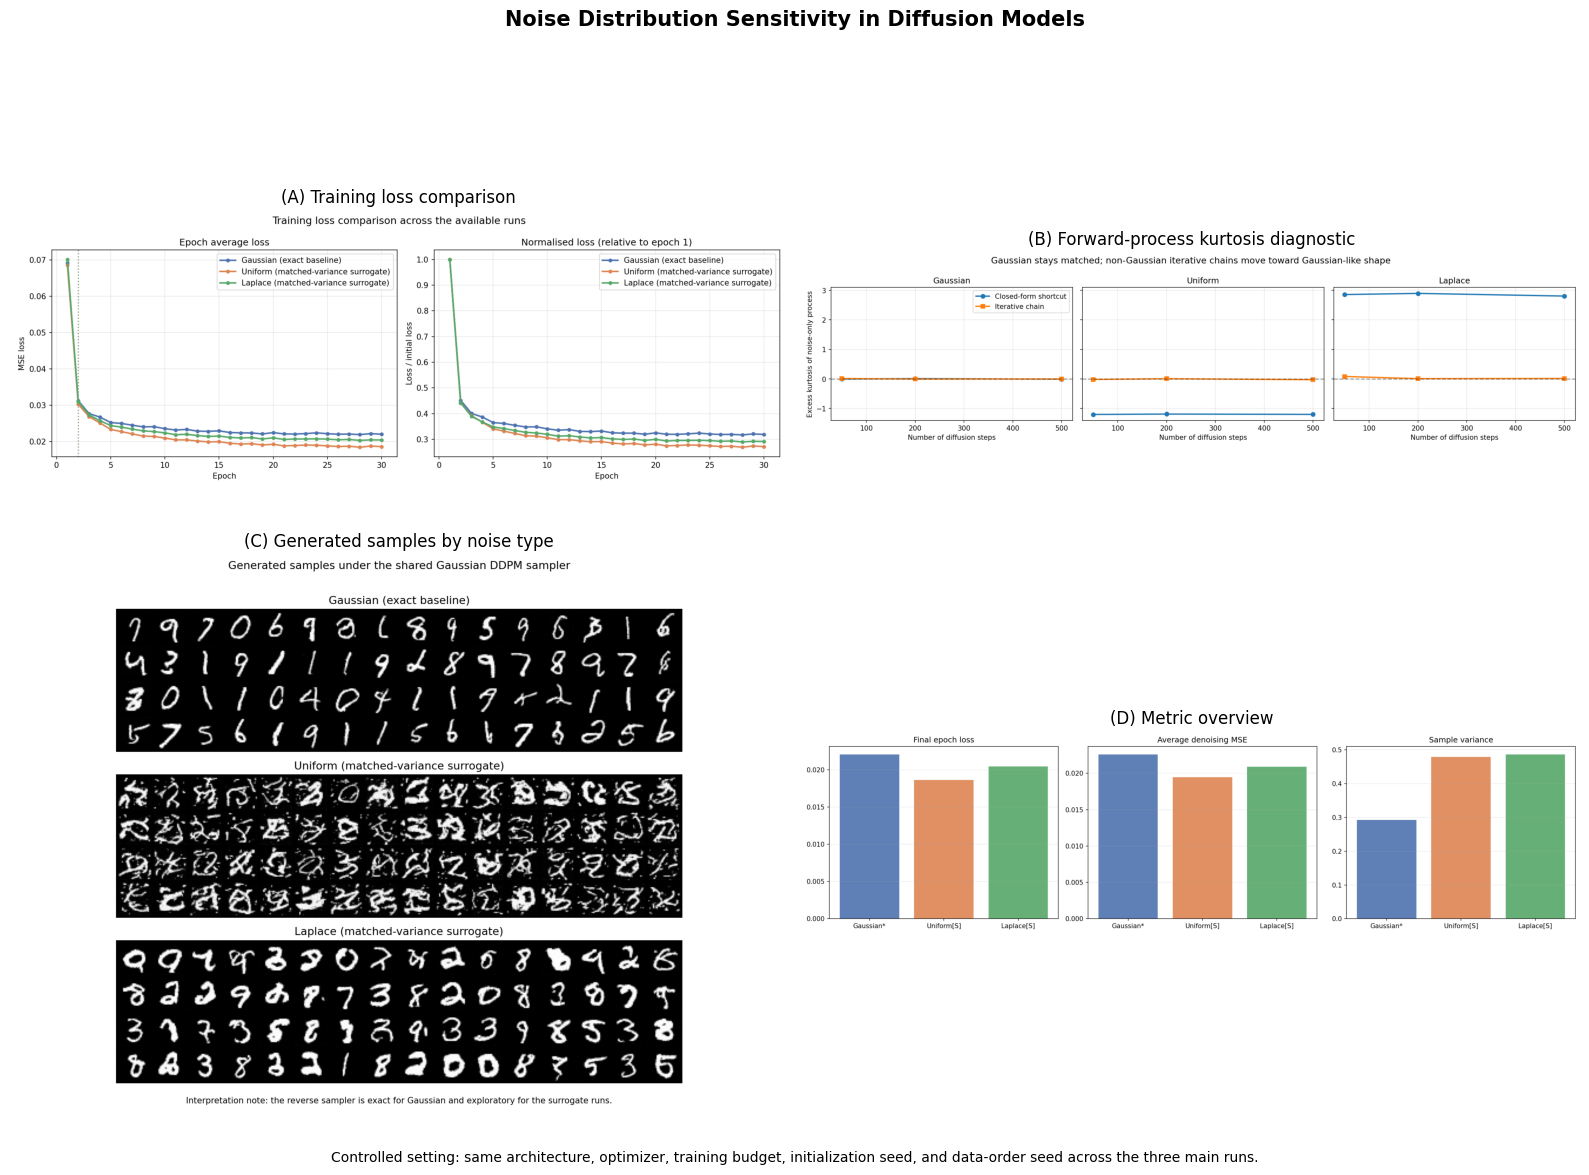

Summary figure saved.


In [35]:
dashboard_specs = [
    ('(A) Training loss comparison', os.path.join(PROJECT_DIR, 'figures', 'loss_comparison.png')),
    ('(B) Forward-process kurtosis diagnostic', os.path.join(PROJECT_DIR, 'figures', 'kurtosis_diagnostic.png')),
    ('(C) Generated samples by noise type', os.path.join(PROJECT_DIR, 'figures', 'samples_comparison.png')),
    ('(D) Metric overview', os.path.join(PROJECT_DIR, 'figures', 'metric_overview.png')),
]

if not os.path.exists(dashboard_specs[-1][1]):
    dashboard_specs[-1] = ('(D) Denoising MSE by timestep', os.path.join(PROJECT_DIR, 'figures', 'mse_vs_timestep.png'))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (title, img_path) in zip(axes.flat, dashboard_specs):
    if os.path.exists(img_path):
        ax.imshow(plt.imread(img_path))
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f'Missing file:\n{os.path.basename(img_path)}', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Noise Distribution Sensitivity in Diffusion Models', fontsize=15, fontweight='bold')
fig.text(
    0.5,
    0.02,
    'Controlled setting: same architecture, optimizer, training budget, initialization seed, and data-order seed across the three main runs.',
    ha='center',
    fontsize=10,
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'summary_figure.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Summary figure saved.')



## 3. Automated Interpretation Note

This section reads the saved evaluation and training summaries and converts them into report-ready statements.



In [36]:
summary_path = os.path.join(PROJECT_DIR, 'logs', 'evaluation_summary.json')
campaign_summary_path = os.path.join(PROJECT_DIR, 'logs', 'training_campaign_summary.json')

if not os.path.exists(summary_path):
    display(Markdown('### Missing evaluation summary\nRun Notebook 5 first so this notebook can generate the final commentary automatically.'))
else:
    with open(summary_path) as f:
        summary = json.load(f)

    campaign_summary = {}
    if os.path.exists(campaign_summary_path):
        with open(campaign_summary_path) as f:
            campaign_summary = json.load(f)

    available = summary.get('available_runs', [])
    missing = summary.get('missing_runs', [])
    metrics = summary.get('metrics', {})
    full_comparison = summary.get('full_comparison_ready', False)
    controls_verified = summary.get('shared_controls_verified')
    campaign_results = campaign_summary.get('results', {})
    control_note = campaign_summary.get(
        'experimental_controls',
        'Same architecture, optimizer, budget, initialization seed, and data-order seed were targeted across runs.',
    )

    lines_md = ['### Current report status', '']
    lines_md.append(f'- Available main runs: **{", ".join(available) if available else "none"}**.')
    if missing:
        lines_md.append(f'- Missing main runs: **{", ".join(missing)}**.')
    else:
        lines_md.append('- All three main runs are available.')

    if controls_verified is True:
        lines_md.append(f'- Experimental controls verified across the available runs: **{control_note}**')
    elif controls_verified is False:
        lines_md.append('- Warning: the saved metadata indicates a mismatch in the training controls across runs.')
    else:
        lines_md.append(f'- Experimental control policy: **{control_note}**')

    for nt in available:
        metric = metrics.get(nt, {})
        label = metric.get('run_label', LABELS[nt])
        loss = metric.get('final_epoch_avg_loss')
        mse = metric.get('avg_denoising_mse')
        variance = metric.get('sample_variance')
        duration = campaign_results.get(nt, {}).get('duration_minutes')
        peak = campaign_results.get(nt, {}).get('peak_memory_gb')

        line = f'- {label}:'
        if loss is not None:
            line += f' final training loss **{loss:.5f}**;'
        if mse is not None:
            line += f' average denoising MSE **{mse:.5f}**;'
        if variance is not None:
            line += f' sample variance **{variance:.5f}**;'
        if duration is not None:
            line += f' runtime **{duration:.1f} min**;'
        if peak is not None:
            line += f' peak GPU memory **{peak:.2f} GB**.'
        lines_md.append(line.rstrip(';'))

    complete_losses = []
    complete_mses = []
    for nt in available:
        metric = metrics.get(nt, {})
        label = metric.get('run_label', nt)
        if metric.get('final_epoch_avg_loss') is not None:
            complete_losses.append((metric['final_epoch_avg_loss'], label))
        if metric.get('avg_denoising_mse') is not None:
            complete_mses.append((metric['avg_denoising_mse'], label))

    if complete_losses:
        best_loss, best_loss_label = sorted(complete_losses, key=lambda x: x[0])[0]
        lines_md.append(f'- Lowest final training loss among the available runs: **{best_loss_label} ({best_loss:.5f})**.')
    if complete_mses:
        best_mse, best_mse_label = sorted(complete_mses, key=lambda x: x[0])[0]
        lines_md.append(f'- Lowest average denoising MSE among the available runs: **{best_mse_label} ({best_mse:.5f})**.')

    if full_comparison:
        lines_md.append('- The three-way comparison is complete and can support a direct cross-distribution discussion.')
    else:
        lines_md.append('- The current report should still be framed as a baseline plus partial comparison until the missing runs are completed.')

    lines_md.extend([
        '',
        '### Interpretation rules',
        '',
        '- Gaussian is the exact DDPM baseline used for the cleanest theoretical interpretation.',
        '- Uniform and Laplace should be described as matched-variance surrogate direct-corruption experiments.',
        '- Reverse sampling in the generated images still uses the standard Gaussian DDPM update for every run.',
    ])

    display(Markdown('\n'.join(lines_md)))



### Current report status

- Available main runs: **gaussian, laplace, uniform**.
- All three main runs are available.
- Experimental controls verified across the available runs: **Same architecture, optimizer, training budget, initialization seed, and data-order seed across all three runs.**
- Gaussian (exact DDPM baseline): final training loss **0.02204**; average denoising MSE **0.02258**; sample variance **0.29293**; runtime **23.1 min**; peak GPU memory **2.28 GB**.
- Laplace (matched-variance surrogate): final training loss **0.02045**; average denoising MSE **0.02092**; sample variance **0.48622**; runtime **22.5 min**; peak GPU memory **2.16 GB**.
- Uniform (matched-variance surrogate): final training loss **0.01862**; average denoising MSE **0.01947**; sample variance **0.47876**; runtime **22.5 min**; peak GPU memory **2.16 GB**.
- Lowest final training loss among the available runs: **Uniform (matched-variance surrogate) (0.01862)**.
- Lowest average denoising MSE among the available runs: **Uniform (matched-variance surrogate) (0.01947)**.
- The three-way comparison is complete and can support a direct cross-distribution discussion.

### Interpretation rules

- Gaussian is the exact DDPM baseline used for the cleanest theoretical interpretation.
- Uniform and Laplace should be described as matched-variance surrogate direct-corruption experiments.
- Reverse sampling in the generated images still uses the standard Gaussian DDPM update for every run.

### 3.1 How to Discuss the Results

Suggested report structure:

- First report what is actually available in the experiment directory.
- Then distinguish the exact Gaussian baseline from the non-Gaussian surrogate runs.
- When the three runs are complete, compare them under the shared controls rather than as unrelated trainings.
- Use the kurtosis diagnostic to explain why the Gaussian shortcut and the non-Gaussian surrogates do not carry the same theoretical status.



### 3.2 Methodology and Limitations

Keep the following points visible in the final write-up:

1. Matching the variance does not make Uniform and Laplace identical to the exact Gaussian DDPM forward law.
2. The displayed generations still use the standard Gaussian DDPM reverse sampler.
3. MNIST is intentionally small and controlled, so the project should be presented as a focused methodological study rather than a large-scale benchmark.



### 3.3 What Was Improved in This Continuation

- the training workflow now runs the three main noise types in one sequential campaign,
- the same initialization seed and data-order seed are reused across the three runs to tighten the comparison,
- the Laplace sampler is stabilised by clipping the inverse-CDF term away from singular values,
- mixed-precision training now uses the current PyTorch AMP interface,
- the evaluation notebook records compact JSON summaries and a metric overview figure,
- the final write-up distinguishes the exact baseline from the surrogate comparisons explicitly.



## 4. Optional Future Work ? Small-T Ablation

This section is now optional by design. Keep it disabled for the main report unless you want an extra exploratory result.


In [37]:
RUN_ABLATION = False  # @param {type:"boolean"}

if RUN_ABLATION:
    unet_path = os.path.join(PROJECT_DIR, 'unet.py')
    if not os.path.exists(unet_path):
        raise FileNotFoundError('Run Notebook 3 first so unet.py is available in the project directory.')

    with open(unet_path) as f:
        exec(f.read(), globals())

    def make_beta_schedule(schedule, T, beta_start, beta_end):
        if schedule == 'linear':
            betas = torch.linspace(beta_start, beta_end, T)
        elif schedule == 'cosine':
            steps = T + 1
            x = torch.linspace(0, T, steps)
            alphas_cumprod = torch.cos(((x / T) + 0.008) / 1.008 * torch.pi / 2) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
            betas = betas.clamp(0, 0.999)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])
        return {'betas': betas, 'alphas': alphas, 'alphas_cumprod': alphas_cumprod, 'alphas_cumprod_prev': alphas_cumprod_prev, 'sqrt_alphas_cumprod': alphas_cumprod.sqrt(), 'sqrt_one_minus_alphas_cumprod': (1 - alphas_cumprod).sqrt()}

    class ForwardDiffusion:
        def __init__(self, schedule, device):
            self.device = device
            self.T = len(schedule['betas'])
            for k, v in schedule.items():
                setattr(self, k, v.to(device))
        def sample_noise(self, shape):
            raise NotImplementedError
        def sample_timestep(self, batch_size):
            return torch.randint(0, self.T, (batch_size,), device=self.device).long()
        def q_sample(self, x_0, t):
            eps = self.sample_noise(x_0.shape)
            sqrt_ab = self.sqrt_alphas_cumprod[t][:, None, None, None]
            sqrt_1ab = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
            return sqrt_ab * x_0 + sqrt_1ab * eps, eps

    class GaussianDiffusion(ForwardDiffusion):
        def sample_noise(self, shape):
            return torch.randn(shape, device=self.device)

    class UniformDiffusion(ForwardDiffusion):
        _a = 3 ** 0.5
        def sample_noise(self, shape):
            return torch.empty(shape, device=self.device).uniform_(-self._a, self._a)

    class LaplaceDiffusion(ForwardDiffusion):
        _b = 2 ** -0.5
        _eps = 1e-6
        def sample_noise(self, shape):
            u = torch.empty(shape, device=self.device).uniform_(-0.5 + self._eps, 0.5 - self._eps)
            safe_term = (1 - 2 * u.abs()).clamp_min(1e-12)
            return -self._b * u.sign() * torch.log(safe_term)

    DIFFUSION_CLASSES = {'gaussian': GaussianDiffusion, 'uniform': UniformDiffusion, 'laplace': LaplaceDiffusion}
    print('Optional ablation definitions loaded.')
else:
    print('Optional ablation disabled. Keep RUN_ABLATION = False for the main report.')


Optional ablation disabled. Keep RUN_ABLATION = False for the main report.


In [38]:
if not RUN_ABLATION:
    ablation_results = {}
    print('Skipping optional ablation run.')
else:
    ABLATION_T_VALUES = [100, 500, 1000]
    ABLATION_EPOCHS = 10
    ABLATION_MODEL_CHANNELS = 32

    def run_ablation(noise_type, T, epochs=ABLATION_EPOCHS, channels=ABLATION_MODEL_CHANNELS):
        torch.manual_seed(42)
        sched = make_beta_schedule('linear', T, 1e-4, 0.02)
        diff = DIFFUSION_CLASSES[noise_type](sched, DEVICE)
        model = UNet(in_channels=1, model_channels=channels, channel_mults=(1, 2, 4)).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        dataset = torchvision.datasets.MNIST(root='/content/data', train=True, download=True, transform=transform)
        loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

        epoch_losses = []
        for epoch in range(epochs):
            model.train()
            running = 0.0
            for x_0, _ in loader:
                x_0 = x_0.to(DEVICE)
                t = diff.sample_timestep(x_0.shape[0])
                opt.zero_grad(set_to_none=True)
                x_t, eps = diff.q_sample(x_0, t)
                loss = F.mse_loss(model(x_t, t), eps)
                if not torch.isfinite(loss):
                    raise RuntimeError(f'Non-finite loss during the optional ablation for {noise_type} at T={T}.')
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                running += loss.item()
            epoch_losses.append(running / len(loader))
            print(f'  {noise_type:10s} T={T:4d} epoch {epoch+1:2d}: {epoch_losses[-1]:.5f}')
        return epoch_losses

    ablation_results = {}
    for T in ABLATION_T_VALUES:
        ablation_results[T] = {}
        for nt in NOISE_TYPES:
            print(f'Running ablation: {nt}, T={T}')
            ablation_results[T][nt] = run_ablation(nt, T)

    print('Optional ablation complete.')


Skipping optional ablation run.


In [39]:
if not RUN_ABLATION:
    print('No ablation plot generated because RUN_ABLATION is False.')
else:
    fig, axes = plt.subplots(1, len(ABLATION_T_VALUES), figsize=(15, 5), sharey=False)

    for ax, T in zip(axes, ABLATION_T_VALUES):
        for nt in NOISE_TYPES:
            if nt not in ablation_results.get(T, {}):
                continue
            losses = ablation_results[T][nt]
            ax.plot(range(1, len(losses) + 1), losses, marker='o', markersize=4, color=COLORS[nt], label=LABELS[nt], linewidth=2)
        ax.set_title(f'T = {T}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg MSE loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Optional ablation: training loss vs T', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'ablation_T.png'), dpi=150)
    plt.show()


No ablation plot generated because RUN_ABLATION is False.


In [40]:
if not RUN_ABLATION:
    print('No ablation bar chart generated because RUN_ABLATION is False.')
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.25
    x = np.arange(len(ABLATION_T_VALUES))

    for i, nt in enumerate(NOISE_TYPES):
        final_losses = [ablation_results[T][nt][-1] if nt in ablation_results.get(T, {}) else float('nan') for T in ABLATION_T_VALUES]
        ax.bar(x + i * bar_width, final_losses, bar_width, label=LABELS[nt], color=COLORS[nt], alpha=0.85, edgecolor='white')

    ax.set_xlabel('T (number of diffusion steps)')
    ax.set_ylabel(f'Final loss (epoch {ABLATION_EPOCHS})')
    ax.set_title('Optional ablation: final loss vs T')
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([str(T) for T in ABLATION_T_VALUES])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'ablation_bar.png'), dpi=150)
    plt.show()


No ablation bar chart generated because RUN_ABLATION is False.


## 5. File Index and Export Options

Recommended export path after the final run:
- Colab: `File -> Download -> Download .html`
- Optional open-source route with Quarto installed locally:
  - `quarto render notebook6_writeup.ipynb --to html`
  - `quarto render notebook6_writeup.ipynb --to pdf`



In [41]:
print('=== PROJECT OUTPUT INDEX ===')
print()

for root, dirs, files in os.walk(PROJECT_DIR):
    dirs.sort()
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root) if level > 0 else 'diffusion_noise_project'
    print(f'{indent}{folder_name}/')
    subindent = '  ' * (level + 1)
    for f in sorted(files):
        size_kb = os.path.getsize(os.path.join(root, f)) / 1024
        print(f'{subindent}{f} ({size_kb:.1f} KB)')

print()
print('Project complete!')
print('Recommended backup: download the executed notebook as HTML from Colab.')
print('Optional Quarto export commands:')
print('  quarto render notebook6_writeup.ipynb --to html')
print('  quarto render notebook6_writeup.ipynb --to pdf')


=== PROJECT OUTPUT INDEX ===

diffusion_noise_project/
  config.json (0.4 KB)
  unet.py (3.3 KB)
  checkpoints/
    gaussian/
      epoch_005.pt (76794.8 KB)
      epoch_010.pt (76815.4 KB)
      epoch_015.pt (76836.1 KB)
      epoch_020.pt (76856.8 KB)
      epoch_025.pt (76877.6 KB)
      epoch_030.pt (76898.3 KB)
    laplace/
      epoch_005.pt (76794.8 KB)
      epoch_010.pt (76815.4 KB)
      epoch_015.pt (76836.1 KB)
      epoch_020.pt (76856.9 KB)
      epoch_025.pt (76877.6 KB)
      epoch_030.pt (76898.3 KB)
    uniform/
      epoch_005.pt (76794.8 KB)
      epoch_010.pt (76815.4 KB)
      epoch_015.pt (76836.1 KB)
      epoch_020.pt (76856.9 KB)
      epoch_025.pt (76877.6 KB)
      epoch_030.pt (76898.3 KB)
  figures/
    beta_schedule.png (99.8 KB)
    campaign_loss_overview.png (131.2 KB)
    campaign_samples.png (478.6 KB)
    forward_diffusion_comparison.png (82.3 KB)
    kurtosis_diagnostic.png (71.0 KB)
    loss_comparison.png (129.1 KB)
    metric_overview.png (47.1 K